# Cross-Linguistic Steering Experiment: Slang Features Across Languages

## Overview
This notebook tests **cross-linguistic steering** using SAE features discovered in Layer 20 of Gemma-2-9B-IT.

### Experimental Design:
1. **Cross-Language Steering**: Use features from Language A to steer sentences in Language B/C
2. **Universal Features**: Use features found in ALL 3 languages to steer each language
3. **Same-Language Baseline**: Use each language's own features for comparison

### Alpha Values Tested:
`[ -150, -100, -50, 0, 50, 100, 150]`

### Evaluation:
Formality scores (0-1) using GPT-4o (LLM as a judge)

# **Install**

In [ ]:
# Install required packages
!pip install -q sae-lens transformer-lens transformers scipy pandas matplotlib seaborn tqdm openai
!pip uninstall numpy -y
!pip install numpy==1.26.4 -q
!pip install --force-reinstall pandas -q

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.1/145.1 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 313.6/313.6 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.2/59.2 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 334.7/334.7 kB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 241.7/241.7 kB 27.2 MB/s eta 0:00:00
Found existing installation: numpy 2.1.3
Uninstalling numpy-2.1.3:
  Successfully uninstalled numpy-2.1.3
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 138.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Instal

# Import

In [ ]:
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from tqdm import tqdm
from functools import partial
from transformers import AutoTokenizer, AutoModelForCausalLM  # For Gemma
from itertools import product
import warnings
import os
from openai import OpenAI
warnings.filterwarnings('ignore')


print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


# HF login

In [ ]:
from huggingface_hub import login
login()

## Load Model

In [ ]:
import torch, transformer_lens, gc

try:
    del hf_model
except NameError:
    pass
gc.collect(); torch.cuda.empty_cache()

tl_model = transformer_lens.HookedTransformer.from_pretrained_no_processing(
    "google/gemma-2-9b-it",
    device="cuda",
    dtype=torch.bfloat16,
)
tl_model.eval()
print(f"✓ {tl_model.cfg.n_layers} layers, d_model={tl_model.cfg.d_model}")

config.json:   0%|          | 0.00/857 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/39.1k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/464 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/47.0k [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.5MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

Loaded pretrained model google/gemma-2-9b-it into HookedTransformer
✓ 42 layers, d_model=3584


# Load SAE for layer 20

In [ ]:
from sae_lens import SAE

print("Loading SAE from Gemma Scope (Layer 20)...")

# load to CPU: only W_dec is needed, and the model is occupying the GPU
_loaded = SAE.from_pretrained(
    release="gemma-scope-9b-it-res-canonical",
    sae_id="layer_20/width_131k/canonical",
    device="cpu",
)
sae = _loaded[0] if isinstance(_loaded, tuple) else _loaded

print("SAE loaded successfully!")
print(f"SAE width: {sae.cfg.d_sae}")
print(f"SAE input dimension: {sae.cfg.d_in}")

Loading SAE from Gemma Scope (Layer 20)...


layer_20/width_131k/average_l0_81/params(…): reconstructing file:   0%|          |  0.00B / 3.76GB            

layer_20/width_131k/average_l0_81/params(…): downloading bytes:           |  0.00B            

SAE loaded successfully!
SAE width: 131072
SAE input dimension: 3584


## Define UNIVERSAL Feature Set



In [ ]:
print("="*80)
print("DEFINING UNIVERSAL FEATURE SET - LAYER 20")
print("="*80)

# ============================================================================
# CROSS-LINGUISTIC CORE (Layer 20)
# Features appearing in the top-100 Delta-ranked list of ALL 3 source
# languages (English, Hebrew, Russian). Source: Layer 20 analysis notebook,
# UNIVERSAL_LAYER20_FEATURES.
# Annotations are pooled avg differential activation frequency.
# ============================================================================
UNIVERSAL_FEATURES = [
    35440,   # Avg Diff: +33.6% (Eng: +52.1%, Heb: +21.3%, Rus: +27.4%)
    93521,   # Avg Diff: +31.6% (Eng: +39.7%, Heb: +13.0%, Rus: +42.0%)
    97003,   # Avg Diff: +21.2% (Eng: +12.8%, Heb: +12.8%, Rus: +38.0%)
    33236,   # Avg Diff: +20.0% (Eng: +43.7%, Heb:  +9.8%, Rus:  +6.3%)
    88782,   # Avg Diff: +14.7% (Eng: +17.0%, Heb:  +6.6%, Rus: +20.7%)
    92777,   # Avg Diff: +11.0% (Eng:  +5.6%, Heb:  +6.3%, Rus: +21.0%)
    20069,   # Avg Diff: +10.5% (Eng: +10.4%, Heb:  +9.8%, Rus: +11.4%)
    71479,   # Avg Diff: +10.1% (Eng:  +7.8%, Heb:  +6.2%, Rus: +16.2%)
    24006,   # Avg Diff:  +9.6% (Eng:  +5.2%, Heb:  +4.5%, Rus: +19.1%)
    46374,   # Avg Diff:  +9.2% (Eng: +15.3%, Heb:  +6.2%, Rus:  +6.1%)
]

# Store in dictionary for easy access
FEATURE_SETS = {
    'universal': UNIVERSAL_FEATURES
}

assert len(UNIVERSAL_FEATURES) == 10, "expected the 10-feature cross-linguistic core"
assert len(set(UNIVERSAL_FEATURES)) == 10, "duplicate feature ids"

print("\nFeature Sets Defined (Layer 20):")
for name, features in FEATURE_SETS.items():
    print(f"  {name.upper():12s}: {len(features)} features - {features}")

print(f"\n✓ Total unique features across all sets: {len(set(sum(FEATURE_SETS.values(), [])))}")

DEFINING UNIVERSAL FEATURE SET - LAYER 20

Feature Sets Defined (Layer 20):
  UNIVERSAL   : 10 features - [35440, 93521, 97003, 33236, 88782, 92777, 20069, 71479, 24006, 46374]

✓ Total unique features across all sets: 10


## 3. Extract Steering Vectors

In [ ]:
print("="*80)
print("EXTRACTING STEERING VECTORS FROM DISCOVERED FEATURES")
print("="*80)

decoder_weights = sae.W_dec.data
print(f"Decoder matrix shape: {decoder_weights.shape}")

# Create steering vectors for each feature set
steering_vectors = {}

for set_name, features in FEATURE_SETS.items():
    # Get vectors for all features in this set
    feature_vectors = []
    for feat_idx in features:
        if feat_idx < decoder_weights.shape[0]:
            feature_vectors.append(decoder_weights[feat_idx].clone())
        else:
            print(f"  Warning: Feature {feat_idx} out of bounds, skipping")

    if feature_vectors:
        # Create mean vector from all features
        mean_vector = torch.stack(feature_vectors).mean(dim=0)
        # Normalize
        mean_vector = mean_vector / mean_vector.norm()
        steering_vectors[set_name] = mean_vector
        print(f"  {set_name.upper():12s} vector created (norm: {mean_vector.norm():.4f})")

print(f"\n✓ Created {len(steering_vectors)} steering vectors")

EXTRACTING STEERING VECTORS FROM DISCOVERED FEATURES
Decoder matrix shape: torch.Size([131072, 3584])
  UNIVERSAL    vector created (norm: 1.0000)

✓ Created 1 steering vectors


## 4. Define Target Sentences in All Languages

In [ ]:
print("="*80)
print("DEFINING TARGET SENTENCES IN ALL LANGUAGES")
print("="*80)

ENGLISH_SENTENCES = [
    "I think that",
    "She believes the new restaurant downtown",
    "In my opinion, the movie was",
    "They feel like the music",
    "The exam results were",
    "The presentation was",
    "The game last night was",
    "The outfit she wore looked",
    "The book I finished was",
    "The car he bought seems",
    "I feel that the concert was",
    "The coffee from that shop tastes",
    "The new phone features are",
    "The vacation we took was",
    "He thought his explanation was",
    "Yo, that party was",
    "Bro, check out this",
    "That beat is so",
    "Dude, the game last night was",
    "Man, this food is",
]

HEBREW_SENTENCES = [
    "אני חושב ש",
    "היא מאמינה שהמסעדה החדשה במרכז העיר",
    "לדעתי, הסרט היה",
    "הם מרגישים שהמוזיקה",
    "תוצאות המבחן היו",
    "המצגת הייתה",
    "המשחק אמש היה",
    "הבגד שהיא לבשה נראה",
    "הספר שסיימתי היה",
    "המכונית שהוא קנה נראית",
    "אני מרגיש שהקונצרט היה",
    "הקפה מהחנות ההיא טעים",
    "התכונות של הטלפון החדש הן",
    "החופשה שלקחנו הייתה",
    "הוא חשב שההסבר שלו היה",
    "יו, המסיבה הייתה",
    "אחי, תבדוק את זה",
    "הביט הזה כל כך",
    "גבר, המשחק אמש היה",
    "אחי, האוכל הזה",
]

RUSSIAN_SENTENCES = [
    "Я думаю, что",
    "Она считает, что новый ресторан в центре города",
    "По моему мнению, фильм был",
    "Они чувствуют, что музыка",
    "Результаты экзамена были",
    "Презентация была",
    "Игра вчера вечером была",
    "Наряд, который она надела, выглядел",
    "Книга, которую я закончил, была",
    "Машина, которую он купил, кажется",
    "Я чувствую, что концерт был",
    "Кофе из того магазина на вкус",
    "Новые функции телефона",
    "Отпуск, который мы взяли, был",
    "Он думал, что его объяснение было",
    "Йо, та вечеринка была",
    "Бро, посмотри на это",
    "Этот бит такой",
    "Чувак, игра вчера была",
    "Мужик, эта еда",
]

GERMAN_SENTENCES = [
    "Ich denke, dass",
    "Sie glaubt, das neue Restaurant in der Innenstadt",
    "Meiner Meinung nach war der Film",
    "Sie haben das Gefühl, dass die Musik",
    "Die Prüfungsergebnisse waren",
    "Die Präsentation war",
    "Das Spiel gestern Abend war",
    "Das Outfit, das sie trug, sah ... aus",
    "Das Buch, das ich beendet habe, war",
    "Das Auto, das er gekauft hat, scheint",
    "Ich finde, dass das Konzert ... war",
    "Der Kaffee aus diesem Laden schmeckt",
    "Die neuen Telefonfunktionen sind",
    "Der Urlaub, den wir gemacht haben, war",
    "Er dachte, seine Erklärung sei",
    "Yo, diese Party war",
    "Alter, schau dir das mal an",
    "Dieser Beat ist so",
    "Alter, das Spiel gestern Abend war",
    "Mann, dieses Essen ist",
]

JAPANESE_SENTENCES = [
    "私は思う",
    "彼女はダウンタウンの新しいレストランが",
    "私の意見では、その映画は",
    "彼らはその音楽が",
    "試験の結果は",
    "プレゼンテーションは",
    "昨夜の試合は",
    "彼女が着ていた服は",
    "読み終えた本は",
    "彼が買った車は",
    "コンサートは",
    "あの店のコーヒーは",
    "新しいスマホの機能は",
    "旅行は",
    "彼は自分の説明が",
    "ねえ、あのパーティーは",
    "なあ、これを見てくれよ",
    "そのビートはめちゃくちゃ",
    "やばい、昨夜の試合は",
    "うわ、この料理は",
]

HINDI_SENTENCES = [
    "मुझे लगता है कि",
    "उसे विश्वास है कि शहर का नया रेस्तरां",
    "मेरी राय में, फ़िल्म",
    "उन्हें लगता है कि संगीत",
    "परीक्षा के परिणाम",
    "प्रेजेंटेशन",
    "कल रात का मैच",
    "उसने जो पोशाक पहनी वह",
    "जो किताब मैंने पूरी की वह",
    "उसने जो गाड़ी खरीदी वह",
    "मुझे लगता है कि कॉन्सर्ट",
    "उस दुकान की कॉफ़ी का स्वाद",
    "नए फ़ोन की विशेषताएं",
    "हमने जो छुट्टियां बिताईं वे",
    "उसे लगा कि उसकी व्याख्या",
    "यार, वो पार्टी तो",
    "भाई, ये देख",
    "वो बीट एकदम",
    "यार, कल रात का मैच",
    "भाई, ये खाना तो",
]

THAI_SENTENCES = [
    "ฉันคิดว่า",
    "เธอเชื่อว่าร้านอาหารใหม่ในเมือง",
    "ในความเห็นของฉัน ภาพยนตร์เรื่องนี้",
    "พวกเขารู้สึกว่าดนตรี",
    "ผลการสอบ",
    "การนำเสนอ",
    "เกมเมื่อคืน",
    "ชุดที่เธอใส่ดู",
    "หนังสือที่ฉันอ่านจบ",
    "รถที่เขาซื้อดูเหมือน",
    "ฉันรู้สึกว่าคอนเสิร์ต",
    "กาแฟจากร้านนั้นมีรสชาติ",
    "ฟีเจอร์ของโทรศัพท์ใหม่",
    "การพักร้อนที่เราไป",
    "เขาคิดว่าคำอธิบายของเขา",
    "เฮ้ ปาร์ตี้นั้น",
    "เพื่อน ดูนี่สิ",
    "บีตนี้มัน",
    "ว้าว เกมเมื่อคืน",
    "โห อาหารนี้",
]

GEORGIAN_SENTENCES = [
    "მე მგონია, რომ",
    "ის დარწმუნებულია, რომ ცენტრში ახალი რესტორანი",
    "ჩემი აზრით, ფილმი",
    "მათ ჰგონიათ, რომ მუსიკა",
    "გამოცდის შედეგები",
    "პრეზენტაცია",
    "გუშინ ღამის თამაში",
    "მის მიერ ჩაცმული ტანსაცმელი",
    "წიგნი, რომელიც წავიკითხე,",
    "მანქანა, რომელიც მან იყიდა,",
    "მე მგონია, რომ კონცერტი",
    "იმ მაღაზიის ყავა გემოთი",
    "ახალი ტელეფონის ფუნქციები",
    "შვებულება, სადაც ვიყავით,",
    "მას ეგონა, რომ მისი ახსნა",
    "ბიჭო, ის წვეულება",
    "ძმაო, შეხედე ამას",
    "ეს ბიტი ასე",
    "ბიჭო, გუშინ ღამის თამაში",
    "კაცო, ეს საჭმელი",
]

AMHARIC_SENTENCES = [
    "እንደሚመስለኝ",
    "በከተማው ያለው አዲሱ ምግብ ቤት",
    "በእኔ አስተያየት ፊልሙ",
    "ሙዚቃው እንደሚሰማቸው",
    "የፈተናው ውጤቶች",
    "አቀራረቡ",
    "ትናንት ምሽት የነበረው ጨዋታ",
    "የለበሰችው ልብስ",
    "ያነበብኩት መጽሐፍ",
    "የገዛው መኪና",
    "ኮንሰርቱ እንደሚሰማኝ",
    "ከዚያ ሱቅ የሚገኘው ቡና",
    "የአዲሱ ስልክ ባህሪያት",
    "የወሰድነው ዕረፍት",
    "ማብራሪያው እንደሚመስለው",
    "ዬ፣ ያ ፓርቲ",
    "ወንድሜ፣ ይህን ተመልከት",
    "ያ ቢት በጣም",
    "ወዳጄ፣ ትናንት ምሽት ጨዋታው",
    "ሰው፣ ይህ ምግብ",
]

N_PROMPTS = 20

SENTENCES = {
    'english':  ENGLISH_SENTENCES[:N_PROMPTS],
    'hebrew':   HEBREW_SENTENCES[:N_PROMPTS],
    'russian':  RUSSIAN_SENTENCES[:N_PROMPTS],
    'german':   GERMAN_SENTENCES[:N_PROMPTS],
    'japanese': JAPANESE_SENTENCES[:N_PROMPTS],
    'hindi':    HINDI_SENTENCES[:N_PROMPTS],
    'thai':     THAI_SENTENCES[:N_PROMPTS],
    'georgian': GEORGIAN_SENTENCES[:N_PROMPTS],
    'amharic':  AMHARIC_SENTENCES[:N_PROMPTS],
}

print("\nSentence Sets Defined:")
for lang, sents in SENTENCES.items():
    assert len(sents) == N_PROMPTS, f"{lang} has {len(sents)}"
    print(f"  {lang.upper():12s}: {len(sents)} sentences")

total_sentences = sum(len(s) for s in SENTENCES.values())
print(f"\n✓ Total sentences: {total_sentences}")

DEFINING TARGET SENTENCES IN ALL LANGUAGES

Sentence Sets Defined:
  ENGLISH     : 20 sentences
  HEBREW      : 20 sentences
  RUSSIAN     : 20 sentences
  GERMAN      : 20 sentences
  JAPANESE    : 20 sentences
  HINDI       : 20 sentences
  THAI        : 20 sentences
  GEORGIAN    : 20 sentences
  AMHARIC     : 20 sentences

✓ Total sentences: 180


## 5. Define Steering Functions

In [ ]:
STEERING_LAYER = 20

def steering_hook(activation, hook, steering_vector, coefficient):
    """Hook function to add steering vector to residual stream."""
    return activation + coefficient * steering_vector.to(activation.device)

def generate_with_steering(prompt, steering_vector, coefficient, max_tokens=50,
                           temperature=0.7, top_p=0.9):
    """Generate text with steering applied."""
    tokens = tl_model.to_tokens(prompt)
    hook_fn = partial(steering_hook, steering_vector=steering_vector, coefficient=coefficient)
    hook_name = f"blocks.{STEERING_LAYER}.hook_resid_post"

    with tl_model.hooks(fwd_hooks=[(hook_name, hook_fn)]):
        output = tl_model.generate(
            tokens,
            max_new_tokens=max_tokens,
            temperature=temperature,
            top_p=top_p,
            do_sample=True if temperature > 0 else False,
        )
    return tl_model.to_string(output[0])

def generate_baseline(prompt, max_tokens=50, temperature=0.7, top_p=0.9):
    """Generate text without steering (baseline)."""
    tokens = tl_model.to_tokens(prompt)
    output = tl_model.generate(
        tokens,
        max_new_tokens=max_tokens,
        temperature=temperature,
        top_p=top_p,
        do_sample=True if temperature > 0 else False,
    )
    return tl_model.to_string(output[0])

def clean_output(full_text, prompt):
    """Clean generated output by removing prompt and special tokens."""
    output = full_text.replace(prompt, "").strip()
    output = output.replace("<bos>", "").replace("<eos>", "")
    output = output.replace("<end_of_turn>", "").replace("<start_of_turn>", "")
    return output.strip()

print("✓ Steering functions defined")
print(f"  Steering layer: {STEERING_LAYER}")

✓ Steering functions defined
  Steering layer: 20


## 6. Run Cross-Linguistic Steering Experiments

In [ ]:
print("="*80)
print("CROSS-LINGUISTIC STEERING EXPERIMENT")
print("="*80)

COEFFICIENTS = [-150, -100, -50, 0, 50, 100, 150]

# Define all experimental conditions
# (sentence_language, feature_source)
# 3 source languages (English, Hebrew, Russian) + 6 zero-shot (German, Japanese,
# Hindi, Thai, Georgian, Amharic)
LANGUAGES = [
    'english', 'hebrew', 'russian',                            # source
    'german', 'japanese', 'hindi', 'thai', 'georgian', 'amharic',  # zero-shot
]
EXPERIMENTS = [(lang, 'universal') for lang in LANGUAGES]

# fail loudly if a language has no sentence list defined
missing = [l for l in LANGUAGES if l not in SENTENCES]
assert not missing, f"no sentences defined for: {missing}"

print(f"Coefficients ({len(COEFFICIENTS)}): {COEFFICIENTS}")
print(f"\nExperimental Conditions ({len(EXPERIMENTS)}):")
for sent_lang, feat_src in EXPERIMENTS:
    print(f"  {feat_src.upper():12s} features → {sent_lang.upper():12s} sentences "
          f"({len(SENTENCES[sent_lang])} prompts)")

# Calculate total generations
total_gens = sum(len(SENTENCES[e[0]]) for e in EXPERIMENTS) * len(COEFFICIENTS)
print(f"\nTotal generations to perform: {total_gens}")

CROSS-LINGUISTIC STEERING EXPERIMENT
Coefficients (7): [-150, -100, -50, 0, 50, 100, 150]

Experimental Conditions (9):
  UNIVERSAL    features → ENGLISH      sentences (20 prompts)
  UNIVERSAL    features → HEBREW       sentences (20 prompts)
  UNIVERSAL    features → RUSSIAN      sentences (20 prompts)
  UNIVERSAL    features → GERMAN       sentences (20 prompts)
  UNIVERSAL    features → JAPANESE     sentences (20 prompts)
  UNIVERSAL    features → HINDI        sentences (20 prompts)
  UNIVERSAL    features → THAI         sentences (20 prompts)
  UNIVERSAL    features → GEORGIAN     sentences (20 prompts)
  UNIVERSAL    features → AMHARIC      sentences (20 prompts)

Total generations to perform: 1260


In [ ]:
print("="*80)
print("RUNNING ALL STEERING EXPERIMENTS (ALL LANGUAGES BATCHED PER COEFFICIENT)")
print("="*80)

tl_model.tokenizer.padding_side = 'left'
if tl_model.tokenizer.pad_token is None:
    tl_model.tokenizer.pad_token = tl_model.tokenizer.eos_token

# flatten every (language, prompt) pair into one list
flat = [(lang, feat, p) for lang, feat in EXPERIMENTS for p in SENTENCES[lang]]
print(f"{len(EXPERIMENTS)} languages × prompts = {len(flat)} prompts per coefficient")
print(f"total generations: {len(flat) * len(COEFFICIENTS)}")

CHUNK = 60          # lower to 30 if you hit OOM
steering_vec = steering_vectors['universal']

def run_chunk(prompts, coefficient, max_tokens=50, temperature=0.7, top_p=0.9):
    tokens = tl_model.to_tokens(prompts, prepend_bos=True, padding_side='left')

    def hook_fn(activation, hook):
        return activation + coefficient * steering_vec.to(activation.device)

    hooks = [] if coefficient == 0 else [(f"blocks.{STEERING_LAYER}.hook_resid_post", hook_fn)]
    with tl_model.hooks(fwd_hooks=hooks):
        out = tl_model.generate(tokens, max_new_tokens=max_tokens,
                                temperature=temperature, top_p=top_p,
                                do_sample=temperature > 0,
                                stop_at_eos=False, verbose=False)
    return [tl_model.to_string(r) for r in out]

all_results = []
for coef in tqdm(COEFFICIENTS, desc="coefficients"):
    texts = []
    for i in range(0, len(flat), CHUNK):
        texts += run_chunk([p for _, _, p in flat[i:i+CHUNK]], coef)
        torch.cuda.empty_cache()

    for (lang, feat, prompt), full_text in zip(flat, texts):
        cut = full_text.find(prompt)
        raw = full_text[cut:] if cut != -1 else full_text
        out = clean_output(raw, prompt).replace("<pad>", "").strip()
        all_results.append({
            'sentence_language': lang,
            'feature_source': feat,
            'experiment_type': 'same_language' if lang == feat else
                               ('universal' if feat == 'universal' else 'cross_language'),
            'prompt': prompt,
            'coefficient': coef,
            'generated_text': out[:300],
            'full_text': (prompt + " " + out)[:400],
            'steering_direction': 'formal' if coef < 0 else ('neutral' if coef == 0 else 'slang'),
        })

    d = "←FORMAL" if coef < 0 else ("BASELINE" if coef == 0 else "SLANG→")
    print(f"  [{coef:+4d}] {d:8s} done — {len(flat)} completions")

results_df = pd.DataFrame(all_results)
print(f"\n✓ Generated {len(results_df)} completions total")
print(results_df.groupby(['sentence_language', 'coefficient']).size().unstack(fill_value=0))

RUNNING ALL STEERING EXPERIMENTS (ALL LANGUAGES BATCHED PER COEFFICIENT)
9 languages × prompts = 180 prompts per coefficient
total generations: 1260


coefficients:  14%|█▍        | 1/7 [00:29<02:55, 29.19s/it]

  [-150] ←FORMAL  done — 180 completions


coefficients:  29%|██▊       | 2/7 [00:58<02:25, 29.17s/it]

  [-100] ←FORMAL  done — 180 completions


...

  [ +50] SLANG→   done — 180 completions


coefficients:  86%|████████▌ | 6/7 [02:54<00:29, 29.13s/it]

  [+100] SLANG→   done — 180 completions


coefficients: 100%|██████████| 7/7 [03:23<00:00, 29.13s/it]

  [+150] SLANG→   done — 180 completions

✓ Generated 1260 completions total
coefficient        -150  -100  -50    0     50    100   150
sentence_language                                          
amharic              20    20    20    20    20    20    20
english              20    20    20    20    20    20    20
georgian             20    20    20    20    20    20    20
german               20    20    20    20    20    20    20
hebrew               20    20    20    20    20    20    20
hindi                20    20    20    20    20    20    20
japanese             20    20    20    20    20    20    20
russian              20    20    20    20    20    20    20
thai                 20    20    20    20    20    20    20


In [ ]:
# Save progress - all results generated so far
progress_df = pd.DataFrame(all_results)
progress_df.to_csv('steering_progress_checkpoint.csv', index=False)

print(f"✓ Saved {len(progress_df)} results to 'steering_progress_checkpoint.csv'")
print(f"\nCompleted experiments:")
for (sent_lang, feat_src) in progress_df.groupby(['sentence_language', 'feature_source']).size().index:
    count = len(progress_df[(progress_df['sentence_language'] == sent_lang) &
                            (progress_df['feature_source'] == feat_src)])
    print(f"  {feat_src} → {sent_lang}: {count} generations")


✓ Saved 1260 results to 'steering_progress_checkpoint.csv'

Completed experiments:
  universal → amharic: 140 generations
  universal → english: 140 generations
  universal → georgian: 140 generations
  universal → german: 140 generations
  universal → hebrew: 140 generations
  universal → hindi: 140 generations
  universal → japanese: 140 generations
  universal → russian: 140 generations
  universal → thai: 140 generations


## 7. call GPT via API

In [ ]:
print("="*80)
print("FILTERING OUT NON-TARGET LANGUAGE OUTPUTS")
print("="*80)

import re

def detect_language(text):
    """Detect the primary script/language of a completion across all nine target languages."""
    if pd.isna(text) or not text or len(str(text).strip()) == 0:
        return 'other'
    text = str(text)

    counts = {
        'japanese': len(re.findall(r'[\u3040-\u309F\u30A0-\u30FF\u4E00-\u9FFF]', text)),
        'hindi':    len(re.findall(r'[\u0900-\u097F]', text)),
        'thai':     len(re.findall(r'[\u0E00-\u0E7F]', text)),
        'georgian': len(re.findall(r'[\u10A0-\u10FF\u2D00-\u2D2F]', text)),
        'amharic':  len(re.findall(r'[\u1200-\u139F]', text)),
        'hebrew':   len(re.findall(r'[\u0590-\u05FF]', text)),
        'russian':  len(re.findall(r'[\u0400-\u04FF]', text)),
        'latin':    len(re.findall(r'[a-zA-Z]', text)),
    }
    # scripts that belong to none of our nine languages
    off_target = (len(re.findall(r'[\u0600-\u06FF]', text)) +      # Arabic
                  len(re.findall(r'[\uAC00-\uD7AF]', text)))       # Korean

    total = sum(counts.values()) + off_target
    if total == 0:
        return 'other'
    if off_target / total > 0.3:
        return 'other'

    best = max(counts, key=counts.get)
    if counts[best] / total <= 0.3:
        return 'other'
    # English and German share Latin script and aren't separated here
    return 'latin' if best == 'latin' else best


# languages written in Latin script — detector cannot tell them apart
LATIN_LANGS = {'english', 'german'}

def is_valid_output(row):
    """Keep outputs in the target language, or code-switched into English."""
    d, target = row['detected_language'], row['sentence_language']
    if target in LATIN_LANGS:
        return d == 'latin'
    return d in (target, 'latin')      # 'latin' here means switched to English


valid_df = results_df.copy()
print("Detecting output languages...")
valid_df['detected_language'] = valid_df['generated_text'].apply(detect_language)

print(f"\nDetected languages (before filtering):")
for lang, count in valid_df['detected_language'].value_counts().items():
    print(f"  {lang}: {count} ({100*count/len(valid_df):.1f}%)")

before_count = len(valid_df)
valid_df = valid_df[valid_df.apply(is_valid_output, axis=1)].copy()
print(f"\n✓ Filtered out {before_count - len(valid_df)} non-target language outputs")
print(f"✓ Remaining: {len(valid_df)} outputs")

print(f"\nRemaining outputs by experiment:")
for (sent_lang, feat_src) in EXPERIMENTS:
    subset = valid_df[(valid_df['sentence_language'] == sent_lang) &
                      (valid_df['feature_source'] == feat_src)]
    breakdown = ", ".join(f"{l}: {c}" for l, c in subset['detected_language'].value_counts().items())
    kept = len(subset)
    print(f"  {feat_src:12s} → {sent_lang:12s}: {kept:3d}/140 kept ({breakdown})")

FILTERING OUT NON-TARGET LANGUAGE OUTPUTS
Detecting output languages...

Detected languages (before filtering):
  latin: 426 (33.8%)
  japanese: 130 (10.3%)
  russian: 127 (10.1%)
  hebrew: 126 (10.0%)
  amharic: 114 (9.0%)
  georgian: 111 (8.8%)
  hindi: 101 (8.0%)
  thai: 100 (7.9%)
  other: 25 (2.0%)

✓ Filtered out 27 non-target language outputs
✓ Remaining: 1233 outputs

Remaining outputs by experiment:
  universal    → english     : 140/140 kept (latin: 140)
  universal    → hebrew      : 139/140 kept (hebrew: 125, latin: 14)
  universal    → russian     : 138/140 kept (russian: 126, latin: 12)
  universal    → german      : 139/140 kept (latin: 139)
  universal    → japanese    : 140/140 kept (japanese: 130, latin: 10)
  universal    → hindi       : 140/140 kept (hindi: 101, latin: 39)
  universal    → thai        : 140/140 kept (thai: 100, latin: 40)
  universal    → georgian    : 129/140 kept (georgian: 111, latin: 18)
  universal    → amharic     : 128/140 kept (amharic: 114,

# Scoring formality scores using GPT-4o-mini

In [ ]:
print("="*80)
print("SCORING FORMALITY WITH GPT-4o")
print("="*80)

all_texts = valid_df['generated_text'].tolist()
print(f"Total texts to score: {len(all_texts)}")

# handles chunking + concurrency + split-on-failure internally
valid_df['formality_score'] = get_formality_scores_batch(all_texts)
valid_df['scoring_method'] = 'gpt4o-mini'

# inspect failures before dropping them
failed = valid_df[valid_df['formality_score'].isna()]
if len(failed):
    print(f"\n{len(failed)} rows failed scoring — distribution:")
    print(failed.groupby(['sentence_language', 'coefficient']).size().unstack(fill_value=0))
    print("\nsample failed completions:")
    for t in failed['generated_text'].head(5):
        print(f"  {t!r}")

before_drop = len(valid_df)
valid_df = valid_df[valid_df['formality_score'].notna()].copy()
print(f"\nDropped {before_drop - len(valid_df)} rows with failed scoring")

valid_df.to_csv('/content/steering_scored_core10.csv', index=False)
print(f"✓ Scored {len(valid_df)} outputs  → saved to /content/steering_scored_core10.csv")
print(f"\nFormality score distribution:")
print(valid_df['formality_score'].describe())

print(f"\nMean formality by coefficient:")
print(valid_df.groupby('coefficient')['formality_score'].agg(['mean', 'std', 'count']))

SCORING FORMALITY WITH GPT-4o
Total texts to score: 1233


scoring: 100%|██████████| 62/62 [00:12<00:00,  4.92it/s]

scored 1233 texts, 1 failed

1 rows failed scoring — distribution:
coefficient        150
sentence_language     
amharic              1

sample failed completions:
  '።'

Dropped 1 rows with failed scoring
✓ Scored 1232 outputs  → saved to /content/steering_scored_core10.csv

Formality score distribution:
count    1232.000000
mean        0.442289
std         0.236696
min         0.000000
25%         0.300000
50%         0.500000
75%         0.600000
max         1.000000
Name: formality_score, dtype: float64

Mean formality by coefficient:
                 mean       std  count
coefficient                           
-150         0.565537  0.173201    177
-100         0.562222  0.165166    180
-50          0.556111  0.216670    180
 0           0.489385  0.209196    179
 50          0.408939  0.232545    179
 100         0.261850  0.161537    173
 150         0.228049  0.209161    164


# pearson correlation

In [ ]:
from scipy.stats import pearsonr, spearmanr

d = valid_df.dropna(subset=['formality_score'])
for label, sub in [("all 7 coeffs  (vs old -0.6436)", d),
                   ("paper range [-150,100]", d[d.coefficient <= 100])]:
    r, p = pearsonr(sub.coefficient, sub.formality_score)
    rs, _ = spearmanr(sub.coefficient, sub.formality_score)
    print(f"{label:32s} n={len(sub):5d}  r={r:+.4f}  rho={rs:+.4f}  p={p:.2e}")

print()
for lang, g in d[d.coefficient <= 100].groupby('sentence_language'):
    r, p = pearsonr(g.coefficient, g.formality_score)
    print(f"{lang:10s} n={len(g):4d}  r={r:+.3f}  p={p:.2e}")

all 7 coeffs  (vs old -0.6436)   n= 1232  r=-0.5244  rho=-0.5330  p=5.43e-88
paper range [-150,100]           n= 1068  r=-0.4434  rho=-0.4456  p=1.16e-52

amharic    n= 115  r=-0.437  p=1.03e-06
english    n= 120  r=-0.506  p=3.62e-09
georgian   n= 114  r=-0.328  p=3.72e-04
german     n= 120  r=-0.458  p=1.47e-07
hebrew     n= 119  r=-0.398  p=7.51e-06
hindi      n= 120  r=-0.425  p=1.33e-06
japanese   n= 120  r=-0.508  p=3.26e-09
russian    n= 120  r=-0.505  p=4.05e-09
thai       n= 120  r=-0.499  p=6.35e-09


# Saving all completions

In [ ]:
print("="*80)
print("SAVING ALL COMPLETIONS")
print("="*80)

import json, datetime

RUN_TAG = "core10_layer20"

# --- 1. full generation set, before any filtering ---
raw_path = f'/content/completions_{RUN_TAG}_raw.csv'
results_df.to_csv(raw_path, index=False)
print(f"raw (unfiltered):    {len(results_df):5d} rows → {raw_path}")

# --- 2. scored set, after language filtering ---
scored_path = f'/content/completions_{RUN_TAG}_scored.csv'
valid_df.to_csv(scored_path, index=False)
print(f"filtered + scored:   {len(valid_df):5d} rows → {scored_path}")

# --- 3. human-readable dump, grouped by language and prompt ---
txt_path = f'/content/completions_{RUN_TAG}.txt'
with open(txt_path, 'w', encoding='utf-8') as f:
    f.write(f"Steering completions — {RUN_TAG}\n")
    f.write(f"features: {UNIVERSAL_FEATURES}\n")
    f.write(f"coefficients: {COEFFICIENTS}\n")
    f.write(f"generated: {datetime.datetime.now():%Y-%m-%d %H:%M}\n")
    f.write("="*80 + "\n\n")
    for lang in results_df['sentence_language'].unique():
        f.write(f"\n{'='*80}\n{lang.upper()}\n{'='*80}\n")
        sub = results_df[results_df['sentence_language'] == lang]
        for prompt in sub['prompt'].unique():
            f.write(f"\nPROMPT: {prompt}\n{'-'*70}\n")
            rows = sub[sub['prompt'] == prompt].sort_values('coefficient')
            for _, r in rows.iterrows():
                score = valid_df.loc[
                    (valid_df.prompt == r['prompt']) &
                    (valid_df.coefficient == r['coefficient']) &
                    (valid_df.sentence_language == r['sentence_language']),
                    'formality_score']
                s = f"{score.iloc[0]:.2f}" if len(score) else "  — "
                f.write(f"  [{r['coefficient']:+4d}] (fml {s})  {r['generated_text']}\n")
print(f"readable dump:            → {txt_path}")

# --- 4. run metadata ---
meta_path = f'/content/run_metadata_{RUN_TAG}.json'
with open(meta_path, 'w') as f:
    json.dump({
        'run_tag': RUN_TAG,
        'layer': STEERING_LAYER,
        'sae': 'gemma-scope-9b-it-res-canonical / layer_20/width_131k/canonical',
        'features': UNIVERSAL_FEATURES,
        'n_features': len(UNIVERSAL_FEATURES),
        'coefficients': COEFFICIENTS,
        'languages': [l for l, _ in EXPERIMENTS],
        'n_prompts_per_language': N_PROMPTS,
        'n_generated': len(results_df),
        'n_after_language_filter': len(valid_df),
        'judge': 'gpt-4o-mini',
        'timestamp': datetime.datetime.now().isoformat(),
    }, f, indent=2, ensure_ascii=False)
print(f"metadata:                 → {meta_path}")

# --- 5. download to your machine ---
try:
    from google.colab import files
    for p in (raw_path, scored_path, txt_path, meta_path):
        files.download(p)
    print("\n✓ downloads initiated — check your browser")
except Exception as e:
    print(f"\n(download skipped: {e}) — grab the files from the Colab file browser")

SAVING ALL COMPLETIONS
raw (unfiltered):     1260 rows → /content/completions_core10_layer20_raw.csv
filtered + scored:    1232 rows → /content/completions_core10_layer20_scored.csv
readable dump:            → /content/completions_core10_layer20.txt
metadata:                 → /content/run_metadata_core10_layer20.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ downloads initiated — check your browser


# Mian paper plot

ZERO-SHOT FORMALITY PLOT


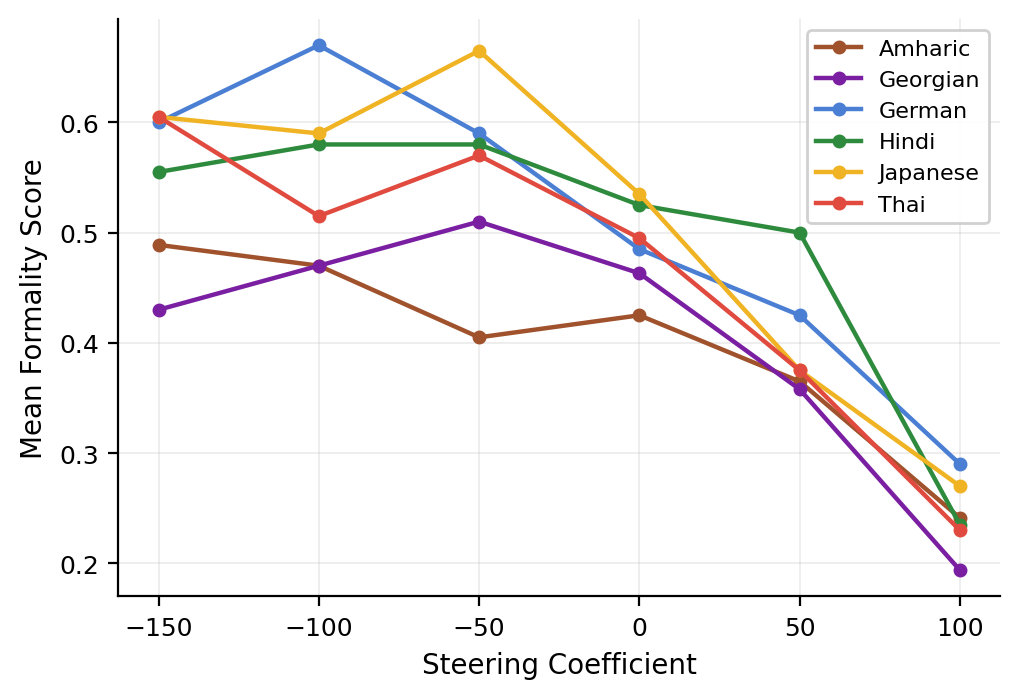

saved → /content/zero_shot_formality_per_language.png

Mean formality by language and coefficient:
coefficient         -150   -100   -50     0      50     100
sentence_language                                          
amharic            0.489  0.470  0.405  0.425  0.365  0.241
georgian           0.430  0.470  0.510  0.463  0.358  0.194
german             0.600  0.670  0.590  0.485  0.425  0.290
hindi              0.555  0.580  0.580  0.525  0.500  0.235
japanese           0.605  0.590  0.665  0.535  0.375  0.270
thai               0.605  0.515  0.570  0.495  0.375  0.230

zero-shot mean: 0.548 at alpha=-150 → 0.245 at alpha=+100


In [ ]:
print("="*80)
print("ZERO-SHOT FORMALITY PLOT")
print("="*80)

import matplotlib.pyplot as plt

ZERO_SHOT = ['amharic', 'georgian', 'german', 'hindi', 'japanese', 'thai']
PLOT_COEFFS = [-150, -100, -50, 0, 50, 100]   # paper operating range

# fixed colours so the figure is reproducible run to run
COLORS = {
    'amharic':  '#a0522d',
    'georgian': '#7b1fa2',
    'german':   '#4a7fd4',
    'hindi':    '#2e8b3d',
    'japanese': '#f0b323',
    'thai':     '#e04a3f',
}

d = valid_df[(valid_df.sentence_language.isin(ZERO_SHOT)) &
             (valid_df.coefficient.isin(PLOT_COEFFS))]

fig, ax = plt.subplots(figsize=(5.2, 3.6), dpi=200)

for lang in ZERO_SHOT:
    g = (d[d.sentence_language == lang]
         .groupby('coefficient')['formality_score'].mean()
         .reindex(PLOT_COEFFS))
    ax.plot(g.index, g.values, marker='o', markersize=4, linewidth=1.6,
            color=COLORS[lang], label=lang.capitalize())

ax.set_xlabel('Steering Coefficient', fontsize=10)
ax.set_ylabel('Mean Formality Score', fontsize=10)
ax.set_xticks(PLOT_COEFFS)
ax.tick_params(labelsize=9)
ax.grid(True, alpha=0.25, linewidth=0.6)
ax.set_axisbelow(True)
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)
ax.legend(fontsize=8, frameon=True, framealpha=0.9, loc='upper right')

plt.tight_layout()
out = '/content/zero_shot_formality_per_language.png'
plt.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print(f"saved → {out}")

# numbers behind the figure
print("\nMean formality by language and coefficient:")
print(d.pivot_table(index='sentence_language', columns='coefficient',
                    values='formality_score', aggfunc='mean').round(3))

zs = d.groupby('coefficient')['formality_score'].mean()
print(f"\nzero-shot mean: {zs.loc[-150]:.3f} at alpha=-150 → {zs.loc[100]:.3f} at alpha=+100")

# Correlations

In [ ]:
from scipy.stats import pearsonr

PAPER = valid_df[valid_df.coefficient <= 100]
SRC   = ['english', 'hebrew', 'russian']
ZS    = ['german', 'japanese', 'hindi', 'thai', 'georgian', 'amharic']

rows = []
for lang in SRC + ZS:
    g = PAPER[PAPER.sentence_language == lang]
    r, p = pearsonr(g.coefficient, g.formality_score)
    rows.append({'language': lang, 'group': 'source' if lang in SRC else 'zero-shot',
                 'n': len(g), 'r': round(r, 3), 'p': f"{p:.1e}",
                 'fml@-150': round(g[g.coefficient == -150].formality_score.mean(), 3),
                 'fml@+100': round(g[g.coefficient == 100].formality_score.mean(), 3)})
print(pd.DataFrame(rows).to_string(index=False))

for name, sub in [('source', PAPER[PAPER.sentence_language.isin(SRC)]),
                  ('zero-shot', PAPER[PAPER.sentence_language.isin(ZS)])]:
    r, p = pearsonr(sub.coefficient, sub.formality_score)
    print(f"\n{name}: n={len(sub)} r={r:+.3f} p={p:.2e}")

language     group   n      r       p  fml@-150  fml@+100
 english    source 120 -0.506 3.6e-09     0.595     0.210
  hebrew    source 119 -0.398 7.5e-06     0.558     0.355
 russian    source 120 -0.505 4.1e-09     0.645     0.315
  german zero-shot 120 -0.458 1.5e-07     0.600     0.290
japanese zero-shot 120 -0.508 3.3e-09     0.605     0.270
   hindi zero-shot 120 -0.425 1.3e-06     0.555     0.235
    thai zero-shot 120 -0.499 6.4e-09     0.605     0.230
georgian zero-shot 114 -0.328 3.7e-04     0.430     0.194
 amharic zero-shot 115 -0.437 1.0e-06     0.489     0.241

source: n=359 r=-0.472 p=2.79e-21

zero-shot: n=709 r=-0.432 p=1.53e-33


# Langague Preservation

In [ ]:
nl = results_df[~results_df.sentence_language.isin(LATIN_LANGS)].copy()
nl['detected_language'] = nl.generated_text.apply(detect_language)
nl['in_target'] = nl.detected_language == nl.sentence_language

for rng, sub in [('all 7 coeffs', nl), ('[-150,100]', nl[nl.coefficient <= 100])]:
    print(f"{rng}: {sub.in_target.mean():.1%} in target language (n={len(sub)})")
print()
print(nl[nl.coefficient <= 100].groupby('sentence_language').in_target.mean().round(3))
print("\nswitches by detected language:")
print(nl[~nl.in_target].detected_language.value_counts())

all 7 coeffs: 82.3% in target language (n=980)
[-150,100]: 90.2% in target language (n=840)

sentence_language
amharic     0.892
georgian    0.883
hebrew      0.983
hindi       0.808
japanese    0.950
russian     0.967
thai        0.833
Name: in_target, dtype: float64

switches by detected language:
detected_language
latin      147
other       24
hebrew       1
russian      1
Name: count, dtype: int64


# Steering samples

In [ ]:
MOVIE = {'english': 2, 'hebrew': 2, 'russian': 2, 'german': 2, 'japanese': 2,
         'hindi': 2, 'thai': 2, 'georgian': 2, 'amharic': 2}   # movie stem index
for lang, idx in MOVIE.items():
    prompt = SENTENCES[lang][idx]
    print(f"\n{'='*70}\n{lang.upper()}: {prompt}")
    sub = results_df[(results_df.sentence_language == lang) & (results_df.prompt == prompt)]
    for a in (-150, 100):
        t = sub[sub.coefficient == a].generated_text.values
        print(f"  [{a:+4d}] {t[0][:160] if len(t) else '—'}")


ENGLISH: In my opinion, the movie was
  [-150] a thought-provoking exploration of the complex relationship between humans and technology, raising important questions about the nature of consciousness, identi
  [+100] so good! I loved the plot, the acting was on point, and the soundtrack was 🔥🔥🔥. 

What did you think about it? 🍿

HEBREW: לדעתי, הסרט היה
  [-150] מרגש ומרהיב. הוא הציג תמונה נרחבת של החיים והסכסוכים של העולם, והעורר בי שאלות עמוקות על נושאים חשובים כגון שלום, מוסר
  [+100] ממש כיף! 🤘

אבל רציני, הוא היה מעולה. 

מה עשתה לך? 😜

(אני אשמח לשמוע מה אתה חושב עליו!)

RUSSIAN: По моему мнению, фильм был
  [-150] пропитан меланхолией и грустью, которые отразили не только судьбы персонажей, но и состояние мира, в котором они жили.

**Меланхолия** присутствовала во многих 
  [+100] крутым! 🔥🔥🔥

Сюжет затянул с самого начала, актеры на высоте, спецэффекты бомба, музыка просто огонь! 💥

Не знаю, кто писал сценарий, но реально молодец! 👏

Одн

GERMAN: Meiner Meinung nach war der Fil

# Preplexity with gemma

PERPLEXITY ANALYSIS (Gemma-2-9B-IT self-perplexity)


perplexity: 100%|██████████| 1260/1260 [03:44<00:00,  5.60it/s]



scored 1246 / 1260 completions

Perplexity by coefficient (all nine languages):
              mean  median     std  count
coefficient                              
-150          5.06    4.12    5.59    180
-100          3.78    3.20    3.93    180
-50           2.85    2.66    0.90    180
 0            3.03    2.58    1.90    179
 50           5.15    3.39   10.34    180
 100          6.94    5.56    5.44    175
 150         33.03    8.75  128.27    172

Median perplexity by language × coefficient:
coefficient        -150  -100  -50    0     50    100   150
sentence_language                                          
amharic             6.4   3.5   3.4   3.3   3.5   5.4  10.5
english             3.4   2.5   2.1   2.0   2.5   3.5   5.3
georgian            3.4   2.9   2.3   2.4   3.1   6.5   8.8
german              3.9   3.1   2.5   2.2   2.9   5.0   8.5
hebrew              5.7   3.8   3.1   2.5   4.2   6.0  13.0
hindi               4.1   2.9   2.3   2.3   3.4   5.0   7.3
japanese       

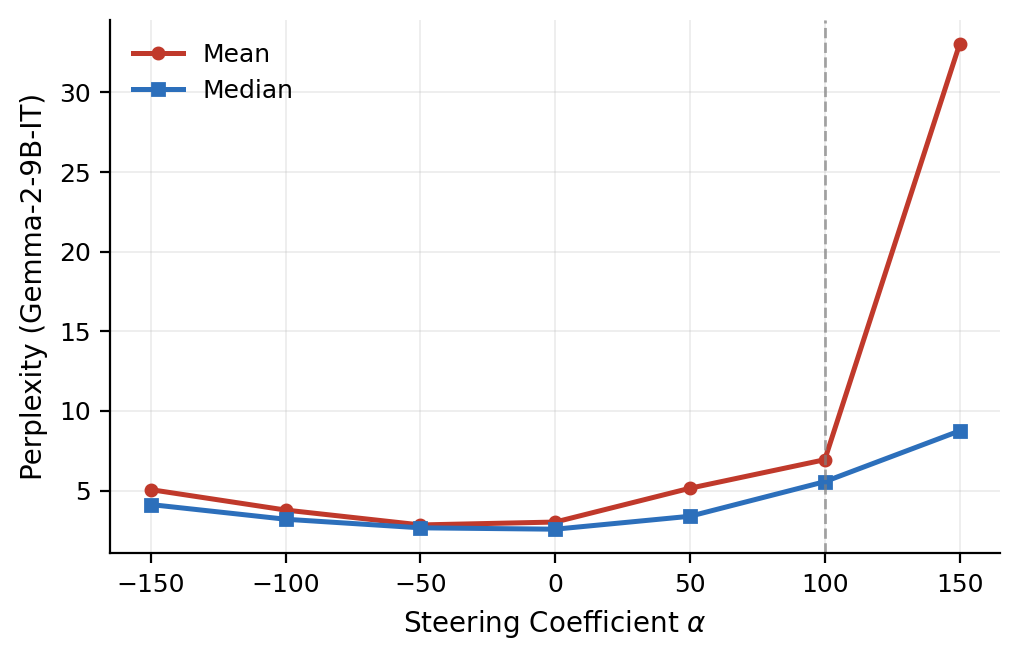

saved → /content/perplexity_gemma_all_languages.png


In [ ]:
print("="*80)
print("PERPLEXITY ANALYSIS (Gemma-2-9B-IT self-perplexity)")
print("="*80)

import numpy as np, torch, matplotlib.pyplot as plt

@torch.no_grad()
def completion_perplexity(prompt, completion):
    """PPL of the completion tokens, conditioned on the prompt, unsteered."""
    if not completion or len(completion.strip()) < 3:
        return np.nan
    p_tok = tl_model.to_tokens(prompt, prepend_bos=True)
    f_tok = tl_model.to_tokens(prompt + " " + completion, prepend_bos=True)
    n_prompt = p_tok.shape[1]
    if f_tok.shape[1] <= n_prompt + 1:
        return np.nan
    # per-token loss; index i is the loss for predicting token i+1
    losses = tl_model(f_tok, return_type="loss", loss_per_token=True)[0]
    comp_losses = losses[n_prompt - 1:]          # only completion tokens
    if comp_losses.numel() == 0:
        return np.nan
    return float(torch.exp(comp_losses.mean()))

# NOTE: no steering hook here — we measure the clean model's perplexity of the
# steered text, which is what "self-perplexity" means in the paper.
ppl = []
for _, r in tqdm(results_df.iterrows(), total=len(results_df), desc="perplexity"):
    ppl.append(completion_perplexity(r['prompt'], r['generated_text']))
results_df['perplexity'] = ppl

d = results_df.dropna(subset=['perplexity'])
# guard against a few degenerate outliers dominating the mean
d = d[d.perplexity < 1e4]

print(f"\nscored {len(d)} / {len(results_df)} completions")
print("\nPerplexity by coefficient (all nine languages):")
print(d.groupby('coefficient')['perplexity'].agg(['mean', 'median', 'std', 'count']).round(2))

print("\nMedian perplexity by language × coefficient:")
print(d.pivot_table(index='sentence_language', columns='coefficient',
                    values='perplexity', aggfunc='median').round(1))

# ---- figure, matching the paper's existing one ----
agg = d.groupby('coefficient')['perplexity'].agg(['mean', 'median'])
fig, ax = plt.subplots(figsize=(5.2, 3.4), dpi=200)
ax.plot(agg.index, agg['mean'],   marker='o', markersize=4, lw=1.8,
        color='#c0392b', label='Mean')
ax.plot(agg.index, agg['median'], marker='s', markersize=4, lw=1.8,
        color='#2c6fbb', label='Median')
ax.axvline(100, color='grey', ls='--', lw=1, alpha=0.7)
ax.set_xlabel(r'Steering Coefficient $\alpha$', fontsize=10)
ax.set_ylabel('Perplexity (Gemma-2-9B-IT)', fontsize=10)
ax.set_xticks(sorted(d.coefficient.unique()))
ax.tick_params(labelsize=9)
ax.grid(True, alpha=0.25, lw=0.6); ax.set_axisbelow(True)
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)
ax.legend(fontsize=9, frameon=False)
plt.tight_layout()
out = '/content/perplexity_gemma_all_languages.png'
plt.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print(f"saved → {out}")

results_df.to_csv('/content/completions_core10_with_ppl.csv', index=False)

# Preplexity with another models

EXTERNAL REFERENCE-MODEL PERPLEXITY (Appendix C)
backed up 1260 completions (Gemma is about to be freed)

GPU free/total after cleanup: [21.4, 42.4] GB

Loading Qwen/Qwen2.5-7B-Instruct ...


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

Hebrew PPL:   0%|          | 0/140 [00:00<?, ?it/s]

saved /content/hebrew_perplexity_dictalm.csv (140 scored)

Median perplexity by coefficient (Qwen, 8 languages):
              mean  median  count
coefficient                      
-150          7.81    5.51    160
-100          6.05    4.85    160
-50           5.36    4.45    160
 0            7.58    5.46    159
 50          14.30    7.10    160
 100         22.95   12.34    155
 150         87.44   23.97    152

Hebrew (dicta-il/dictalm2.0-instruct):
              mean  median  count
coefficient                      
-150         10.08    9.64     20
-100          7.89    7.22     20
-50           6.58    5.60     20
 0            4.77    4.42     20
 50           8.42    7.41     20
 100          9.34    8.83     20
 150         13.62   10.25     20


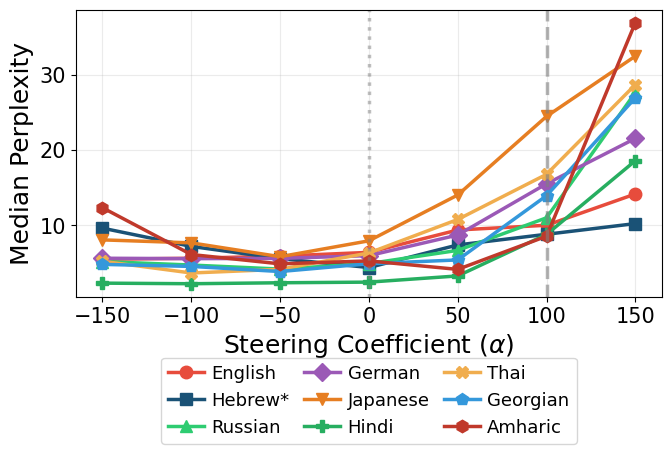

saved → /content/perplexity_median_all_languages.png


In [ ]:
print("="*80)
print("EXTERNAL REFERENCE-MODEL PERPLEXITY (Appendix C)")
print("="*80)

import gc, torch, numpy as np, pandas as pd, matplotlib, matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer
from tqdm.auto import tqdm

# results_df must already hold this run's completions
assert 'results_df' in globals() and len(results_df) > 1000, "generate completions first"
results_df.to_csv('/content/completions_backup_before_refmodels.csv', index=False)
print(f"backed up {len(results_df)} completions (Gemma is about to be freed)\n")

# ---------- 1. free Gemma + SAE ----------
for name in ['tl_model', 'hf_model', 'sae', 'dec', 'decoder_weights']:
    if name in globals():
        del globals()[name]
gc.collect(); torch.cuda.empty_cache()
print(f"GPU free/total after cleanup: {[round(x/1e9,1) for x in torch.cuda.mem_get_info()]} GB")


# ---------- 2. generic perplexity scorer ----------
@torch.no_grad()
def score_with_model(df, model, tok, desc):
    """Perplexity of each completion, conditioned on its prompt."""
    out = []
    for _, r in tqdm(df.iterrows(), total=len(df), desc=desc):
        prompt, comp = str(r['prompt']), str(r['generated_text'])
        if not comp or len(comp.strip()) < 3:
            out.append(np.nan); continue
        try:
            p_ids = tok(prompt, return_tensors='pt').input_ids
            f_ids = tok(prompt + " " + comp, return_tensors='pt').input_ids.to(model.device)
            n_p = p_ids.shape[1]
            if f_ids.shape[1] <= n_p + 1:
                out.append(np.nan); continue
            logits = model(f_ids).logits[0, :-1]              # predict token i+1
            targets = f_ids[0, 1:]
            losses = torch.nn.functional.cross_entropy(
                logits.float(), targets, reduction='none')
            comp_loss = losses[n_p - 1:]
            out.append(float(torch.exp(comp_loss.mean())) if comp_loss.numel() else np.nan)
        except Exception:
            out.append(np.nan)
    return out


def load_model(model_id):
    tok = AutoTokenizer.from_pretrained(model_id)
    m = AutoModelForCausalLM.from_pretrained(
        model_id, torch_dtype=torch.bfloat16,
        low_cpu_mem_usage=True, device_map={"": 0})
    m.eval()
    return m, tok


def free(*names):
    for n in names:
        if n in globals():
            del globals()[n]
    gc.collect(); torch.cuda.empty_cache()


# ---------- 3. Qwen2.5-7B-Instruct: all languages except Hebrew ----------
QWEN_ID = "Qwen/Qwen2.5-7B-Instruct"
print(f"\nLoading {QWEN_ID} ...")
qwen_model, qwen_tok = load_model(QWEN_ID)

non_heb = results_df[results_df.sentence_language != 'hebrew'].copy()
non_heb['perplexity'] = score_with_model(non_heb, qwen_model, qwen_tok, "Qwen PPL")
non_heb['reference_model'] = QWEN_ID
non_heb.to_csv('/content/perplexity_results.csv', index=False)
print(f"saved /content/perplexity_results.csv ({non_heb.perplexity.notna().sum()} scored)")

free('qwen_model', 'qwen_tok')
print(f"GPU free/total: {[round(x/1e9,1) for x in torch.cuda.mem_get_info()]} GB")


# ---------- 4. Hebrew reference model ----------
# NOTE: your paper names BLOOM-7b1; your old plotting cell reads a *dictalm* file.
# Set HEB_ID to whichever you actually used and make the paper match.
HEB_ID = "dicta-il/dictalm2.0-instruct"     # or "bigscience/bloom-7b1"
print(f"\nLoading {HEB_ID} for Hebrew ...")
heb_model, heb_tok = load_model(HEB_ID)

heb = results_df[results_df.sentence_language == 'hebrew'].copy()
heb['perplexity'] = score_with_model(heb, heb_model, heb_tok, "Hebrew PPL")
heb['reference_model'] = HEB_ID
heb.to_csv('/content/hebrew_perplexity_dictalm.csv', index=False)
print(f"saved /content/hebrew_perplexity_dictalm.csv ({heb.perplexity.notna().sum()} scored)")

free('heb_model', 'heb_tok')


# ---------- 5. summary ----------
qwen_df = non_heb[non_heb.perplexity < 10000].dropna(subset=['perplexity'])
heb_df  = heb[heb.perplexity < 10000].dropna(subset=['perplexity'])

print("\nMedian perplexity by coefficient (Qwen, 8 languages):")
print(qwen_df.groupby('coefficient')['perplexity'].agg(['mean','median','count']).round(2))
print(f"\nHebrew ({HEB_ID}):")
print(heb_df.groupby('coefficient')['perplexity'].agg(['mean','median','count']).round(2))


# ---------- 6. figure ----------
matplotlib.rcParams.update({
    'font.size': 16, 'axes.labelsize': 18,
    'xtick.labelsize': 15, 'ytick.labelsize': 15,
    'legend.fontsize': 13, 'lines.linewidth': 2.5, 'lines.markersize': 9,
})
fig, ax = plt.subplots(figsize=(7, 5))

lang_colors = {'english':'#E74C3C','hebrew':'#1A5276','russian':'#2ECC71',
               'german':'#9B59B6','japanese':'#E67E22','hindi':'#27AE60',
               'thai':'#F0AD4E','georgian':'#3498DB','amharic':'#C0392B'}
lang_markers = {'english':'o','hebrew':'s','russian':'^','german':'D','japanese':'v',
                'hindi':'P','thai':'X','georgian':'p','amharic':'h'}
lang_order = ['english','hebrew','russian','german','japanese','hindi','thai','georgian','amharic']

for lang in lang_order:
    sub = heb_df if lang == 'hebrew' else qwen_df[qwen_df.sentence_language == lang]
    if not len(sub):
        continue
    med = sub.groupby('coefficient')['perplexity'].median()
    ax.plot(med.index, med.values, marker=lang_markers[lang], color=lang_colors[lang],
            label=f'{lang.capitalize()}*' if lang == 'hebrew' else lang.capitalize(),
            linewidth=2.5, markersize=9)

ax.axvline(x=0, color='gray', linestyle=':', alpha=0.5)
ax.axvline(x=100, color='gray', linestyle='--', alpha=0.6)
ax.set_xlabel('Steering Coefficient ($\\alpha$)')
ax.set_ylabel('Median Perplexity')
ax.set_xticks(sorted(results_df.coefficient.unique()))
ax.grid(True, alpha=0.25)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=3,
          frameon=True, columnspacing=0.8, handletextpad=0.4)

fig.tight_layout()
fig.savefig('/content/perplexity_median_all_languages.png', dpi=300, bbox_inches='tight')
plt.show()
matplotlib.rcParams.update(matplotlib.rcParamsDefault)
print("saved → /content/perplexity_median_all_languages.png")

# Geometrical Analysis

FIGURE 1: PCA PANELS FOR LAYER 9 AND LAYER 20
shared random sample: 200 features, seed 200, first five [85137, 18487, 123075, 39565, 58493]


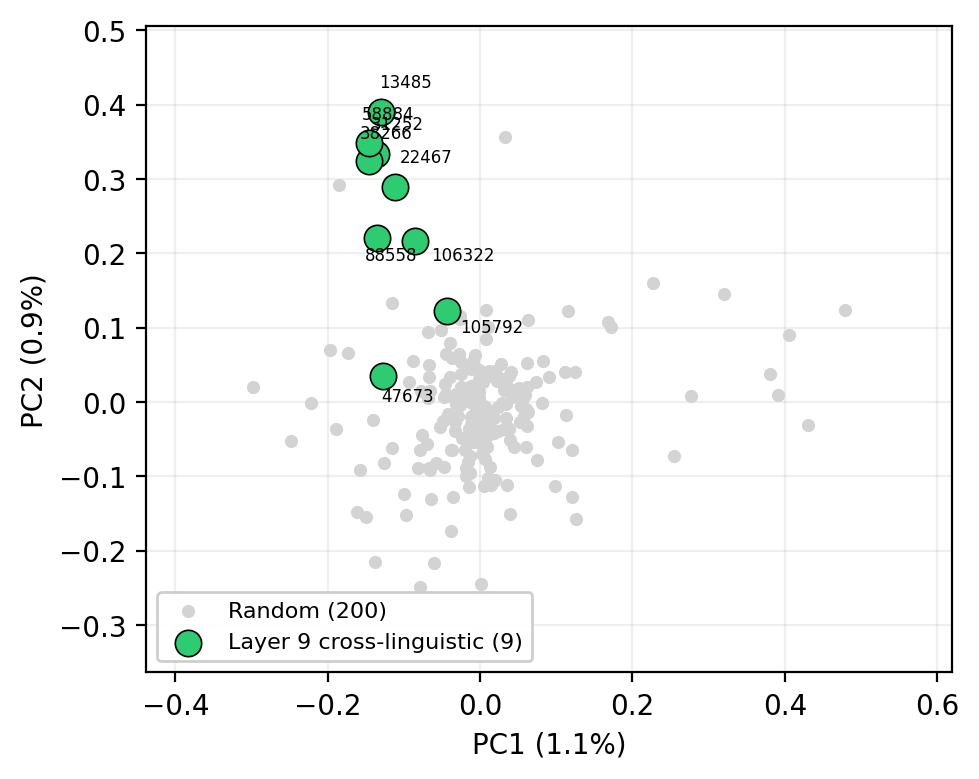

Layer 9: 9 features, within-group cos 0.0652, island 4.34x  ->  /content/layer_9_pca.png


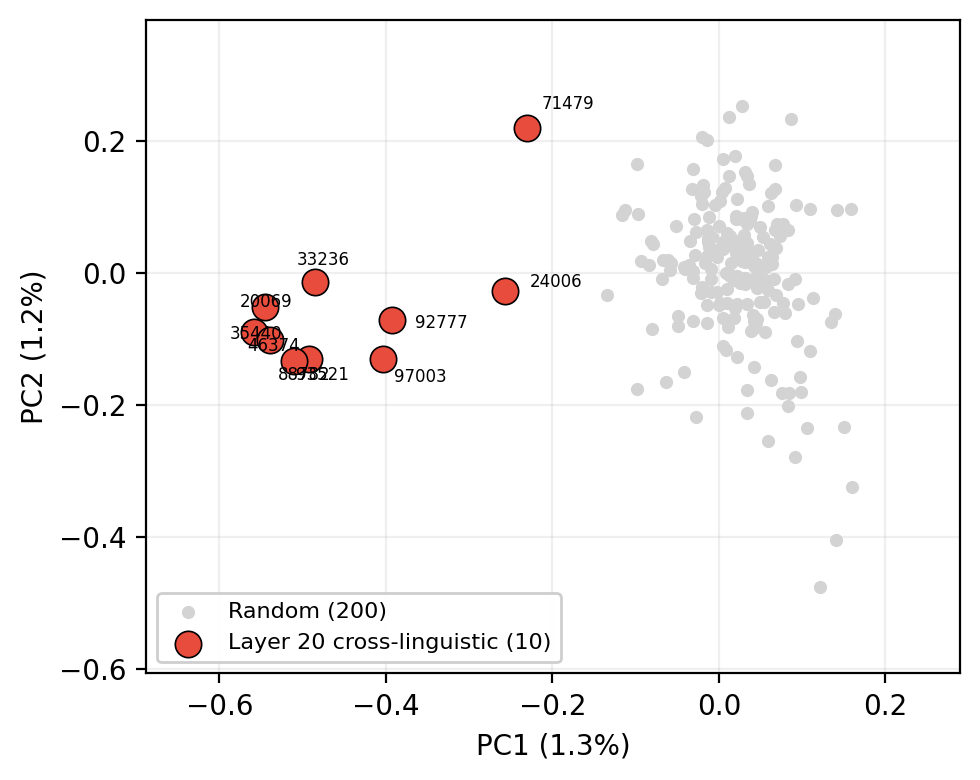

Layer 20: 10 features, within-group cos 0.1523, island 7.82x  ->  /content/layer_20_pca.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


LaTeX: replace figures/layer_9_pca.png and figures/layer_20_pca.png
  sub-caption (a): Layer 9  (island score 4.4$\times$)   [keep published]
  sub-caption (b): Layer 20 (island score 7.8$\times$)
  §5.3 body: Layer 9  0.065 / 4.4x   |   Layer 20  0.152 / 7.8x
Do NOT regenerate cosine_sim_20.png — Appendix C stays as published.


In [ ]:
print("="*80)
print("FIGURE 1: PCA PANELS FOR LAYER 9 AND LAYER 20")
print("="*80)

import gc, numpy as np, matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sae_lens import SAE

CORE = {9:  [13485, 22467, 31252, 38266, 47673, 58884, 88558, 105792, 106322],
        20: [35440, 93521, 97003, 33236, 88782, 92777, 20069, 71479, 24006, 46374]}
COLOR   = {9: '#2ecc71', 20: '#e74c3c'}
N_RAND  = 200
D_SAE   = 131072
RANDOM_SEED = 200

# one shared random sample, excluding every core feature from either layer
_pool = np.setdiff1d(np.arange(D_SAE), np.array(CORE[9] + CORE[20]))
RAND_IDX = np.random.default_rng(RANDOM_SEED).choice(_pool, N_RAND, replace=False)
print(f"shared random sample: {N_RAND} features, seed {RANDOM_SEED}, "
      f"first five {RAND_IDX[:5].tolist()}")

def island(dec, feats, n_rand=1000, n_seeds=5):
    g = dec[feats] / np.linalg.norm(dec[feats], axis=1, keepdims=True)
    within = (g @ g.T)[np.triu_indices(len(feats), 1)].mean()
    pool = np.setdiff1d(np.arange(dec.shape[0]), feats)
    ac = []
    for s in range(n_seeds):
        r = dec[np.random.default_rng(s).choice(pool, n_rand, replace=False)]
        r = r / np.linalg.norm(r, axis=1, keepdims=True)
        ac.append(np.abs(g @ r.T).mean())
    return within, within / np.mean(ac)

for layer in (9, 20):
    _l = SAE.from_pretrained(release="gemma-scope-9b-it-res-canonical",
                             sae_id=f"layer_{layer}/width_131k/canonical", device="cpu")
    sae = _l[0] if isinstance(_l, tuple) else _l
    dec = sae.W_dec.detach().float().numpy()
    assert dec.shape[0] == D_SAE, f"unexpected SAE width {dec.shape[0]}"
    feats = CORE[layer]

    w, s = island(dec, feats)

    X = np.vstack([dec[feats], dec[RAND_IDX]])          # same RAND_IDX both layers
    X = X / np.linalg.norm(X, axis=1, keepdims=True)
    p = PCA(n_components=2).fit(X); Z = p.transform(X); ev = p.explained_variance_ratio_

    fig, ax = plt.subplots(figsize=(5, 4), dpi=200)
    ax.scatter(Z[len(feats):, 0], Z[len(feats):, 1], s=14, c='lightgrey',
               label=f'Random ({N_RAND})', zorder=1)
    ax.scatter(Z[:len(feats), 0], Z[:len(feats), 1], s=90, c=COLOR[layer],
               edgecolors='black', linewidths=0.6, zorder=3,
               label=f'Layer {layer} cross-linguistic ({len(feats)})')
    cx, cy = Z[:len(feats), 0].mean(), Z[:len(feats), 1].mean()
    for i, f in enumerate(feats):
        dx, dy = Z[i, 0] - cx, Z[i, 1] - cy
        n = max((dx*dx + dy*dy) ** 0.5, 1e-9)
        ax.annotate(str(f), (Z[i, 0], Z[i, 1]), fontsize=6, zorder=4,
                    xytext=(9*dx/n, 9*dy/n), textcoords='offset points')
    ax.margins(0.18)
    ax.set_xlabel(f'PC1 ({ev[0]:.1%})'); ax.set_ylabel(f'PC2 ({ev[1]:.1%})')
    ax.legend(fontsize=8, loc='lower left', framealpha=0.95)
    ax.grid(alpha=0.2); ax.set_axisbelow(True)
    plt.tight_layout()
    out = f'/content/layer_{layer}_pca.png'
    plt.savefig(out, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Layer {layer}: {len(feats)} features, within-group cos {w:.4f}, "
          f"island {s:.2f}x  ->  {out}")

    del sae, dec; gc.collect()

try:
    from google.colab import files
    files.download('/content/layer_9_pca.png')
    files.download('/content/layer_20_pca.png')
except Exception as e:
    print(f"(download skipped: {e})")

print("\n" + "="*80)
print("LaTeX: replace figures/layer_9_pca.png and figures/layer_20_pca.png")
print("  sub-caption (a): Layer 9  (island score 4.4$\\times$)   [keep published]")
print("  sub-caption (b): Layer 20 (island score 7.8$\\times$)")
print("  §5.3 body: Layer 9  0.065 / 4.4x   |   Layer 20  0.152 / 7.8x")
print("Do NOT regenerate cosine_sim_20.png — Appendix C stays as published.")
print("="*80)

# Random Feature Steering Ablation

In [ ]:
import gc, torch, numpy as np, pandas as pd
from tqdm.auto import tqdm
from scipy.stats import pearsonr
import transformer_lens
from sae_lens import SAE

print(f"GPU free/total: {[round(x/1e9,1) for x in torch.cuda.mem_get_info()]} GB")

tl_model = transformer_lens.HookedTransformer.from_pretrained_no_processing(
    "google/gemma-2-9b-it", device="cuda", dtype=torch.bfloat16)
tl_model.eval()
tl_model.tokenizer.padding_side = 'left'
if tl_model.tokenizer.pad_token is None:
    tl_model.tokenizer.pad_token = tl_model.tokenizer.eos_token
print(f"GPU free after Gemma: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB")

_l = SAE.from_pretrained(release="gemma-scope-9b-it-res-canonical",
                         sae_id="layer_20/width_131k/canonical", device="cpu")
sae = _l[0] if isinstance(_l, tuple) else _l
dec = sae.W_dec.data
print("SAE ready", tuple(dec.shape))

GPU free/total: [21.5, 42.4] GB


Loading weights:   0%|          | 0/464 [00:00<?, ?it/s]

Loaded pretrained model google/gemma-2-9b-it into HookedTransformer
GPU free after Gemma: 1.1 GB
SAE ready (131072, 3584)


In [ ]:
dec = sae.W_dec.data
print("dec ready", tuple(dec.shape))

dec ready (131072, 3584)


In [ ]:
STEERING_LAYER = 20
CORE = [35440, 93521, 97003, 33236, 88782, 92777, 20069, 71479, 24006, 46374]
COEFS = [-150, 0, 150]
N_SEEDS = 5
LANGS = ['english', 'german']

def make_vec(idx):
    v = dec[idx].float().mean(0)
    return (v / v.norm()).to("cuda", dtype=torch.bfloat16)

vectors = {'universal': make_vec(CORE)}
pool = torch.tensor(sorted(set(range(dec.shape[0])) - set(CORE)))
for s in range(N_SEEDS):
    torch.manual_seed(2000 + s)
    vectors[f'random_{s}'] = make_vec(pool[torch.randperm(len(pool))[:len(CORE)]].tolist())
print(f"{len(vectors)} vectors, {len(CORE)} features each")

del dec, sae; gc.collect()

CHUNK = 20
def run(prompts, vec, coef):
    tok = tl_model.to_tokens(prompts, prepend_bos=True, padding_side='left')
    def hook_fn(activation, hook):
        return activation + coef * vec.to(activation.device)
    hooks = [] if coef == 0 else [(f"blocks.{STEERING_LAYER}.hook_resid_post", hook_fn)]
    with tl_model.hooks(fwd_hooks=hooks):
        out = tl_model.generate(tok, max_new_tokens=50, temperature=0.7, top_p=0.9,
                                do_sample=True, stop_at_eos=False, verbose=False)
    return [tl_model.to_string(r) for r in out]

rows = []
for name, vec in vectors.items():
    for lang in LANGS:
        sents = SENTENCES[lang]
        for coef in tqdm(COEFS, desc=f"{name}->{lang}", leave=False):
            texts = []
            for i in range(0, len(sents), CHUNK):
                texts += run(sents[i:i+CHUNK], vec, coef)
                torch.cuda.empty_cache()
            for p, ft in zip(sents, texts):
                cut = ft.find(p)
                raw = ft[cut:] if cut != -1 else ft
                rows.append({'vector': name, 'language': lang, 'coefficient': coef,
                             'prompt': p,
                             'generated_text': clean_output(raw, p).replace("<pad>","").strip()[:300]})
    print(f"done {name}")

abl_df = pd.DataFrame(rows)
abl_df.to_csv('/content/random_ablation_raw.csv', index=False)
print(f"generated {len(abl_df)}")

6 vectors, 10 features each


universal->english:   0%|          | 0/3 [00:00<?, ?it/s]

universal->german:   0%|          | 0/3 [00:00<?, ?it/s]

done universal


random_0->english:   0%|          | 0/3 [00:00<?, ?it/s]

...

random_3->german:   0%|          | 0/3 [00:00<?, ?it/s]

done random_3


random_4->english:   0%|          | 0/3 [00:00<?, ?it/s]

random_4->german:   0%|          | 0/3 [00:00<?, ?it/s]

done random_4
generated 720


In [ ]:
# ============================================================================
# SCORE THE RANDOM-FEATURE ABLATION  (self-contained: no model needed)
# ============================================================================
import os, re, json, time, random
import numpy as np, pandas as pd
from concurrent.futures import ThreadPoolExecutor
from scipy.stats import pearsonr, ttest_1samp
from tqdm.auto import tqdm
from openai import OpenAI

# ---------- data: use in-memory abl_df, else load the saved CSV ----------
if 'abl_df' not in globals():
    abl_df = pd.read_csv('/content/random_ablation_raw.csv')
print(f"{len(abl_df)} rows | vectors: {abl_df.vector.nunique()} | "
      f"languages: {sorted(abl_df.language.unique())}")

# ---------- OpenAI client ----------
try:
    from google.colab import userdata
    _key = userdata.get('OPENAI_API_KEY')
except Exception:
    _key = os.environ.get('OPENAI_API_KEY')
assert _key, "OPENAI_API_KEY not found (Colab left sidebar > key icon)"
client = OpenAI(api_key=_key)

BATCH_SIZE, MAX_WORKERS = 20, 12

def _call(texts, max_retries=4):
    listing = "\n".join(f'{i+1}. "{t}"' for i, t in enumerate(texts))
    prompt = (f"Rate the formality of each text below on a scale from 0 to 1.\n"
              "- 0 = very informal, casual, slang, colloquial\n"
              "- 1 = very formal, professional, academic\n\n"
              f"Return exactly {len(texts)} scores, one per text, in the same order.\n"
              "Respond with ONLY a JSON array of numbers wrapped in tags like this:\n"
              "[CLASSIFICATION_START][0.2, 0.8, 0.5][CLASSIFICATION_END]\n\n"
              f"Texts:\n{listing}")
    for attempt in range(max_retries):
        try:
            r = client.chat.completions.create(
                model="gpt-4o-mini",
                messages=[{"role": "system", "content":
                           "You are a formality scorer. Always wrap your response in "
                           "[CLASSIFICATION_START] and [CLASSIFICATION_END] tags."},
                          {"role": "user", "content": prompt}],
                max_tokens=20 * len(texts) + 50, temperature=0)
            m = re.search(r'\[CLASSIFICATION_START\]\s*(.*?)\s*\[CLASSIFICATION_END\]',
                          r.choices[0].message.content.strip(), re.DOTALL)
            if not m:
                raise ValueError("tags not found")
            s = json.loads(m.group(1).strip())
            if len(s) != len(texts):
                raise ValueError(f"expected {len(texts)}, got {len(s)}")
            return [min(max(0.0, float(x)), 1.0) for x in s]
        except Exception:
            if attempt < max_retries - 1:
                time.sleep((2 ** attempt) + random.random())
    return None

def _recursive(texts):
    s = _call(texts)
    if s is not None:
        return s
    if len(texts) == 1:
        return [float('nan')]
    mid = len(texts) // 2
    return _recursive(texts[:mid]) + _recursive(texts[mid:])

def _batch(texts):
    out = [float('nan')] * len(texts)
    idx = [i for i, t in enumerate(texts) if t and len(str(t).strip()) >= 3]
    if not idx:
        return out
    for i, s in zip(idx, _recursive([str(texts[i])[:300] for i in idx])):
        out[i] = s
    return out

def score_all(texts):
    chunks = [texts[i:i+BATCH_SIZE] for i in range(0, len(texts), BATCH_SIZE)]
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
        res = list(tqdm(ex.map(_batch, chunks), total=len(chunks), desc="scoring"))
    flat = [s for c in res for s in c]
    print(f"scored {len(flat)}, {sum(1 for s in flat if s != s)} failed")
    return flat

# ---------- score ----------
abl_df['formality_score'] = score_all(abl_df['generated_text'].tolist())
abl_df = abl_df[abl_df.formality_score.notna()].copy()
abl_df.to_csv('/content/random_ablation_scored.csv', index=False)

# ---------- Appendix H numbers ----------
print("\n" + "="*70)
print("APPENDIX H — paste these into Table 11 and the prose")
print("="*70)
for lang in sorted(abl_df.language.unique()):
    d = abl_df[abl_df.language == lang]
    u = d[d.vector == 'universal']
    r_u, p_u = pearsonr(u.coefficient, u.formality_score)
    rs = [pearsonr(g.coefficient, g.formality_score)[0]
          for _, g in d[d.vector != 'universal'].groupby('vector')]
    t, p_t = ttest_1samp(np.abs(rs), abs(r_u))
    base = d[(d.vector != 'universal') & (d.coefficient.abs() == 150)].formality_score.mean()
    print(f"\n{lang.upper()}")
    print(f"  Universal            r = {r_u:+.3f}   p = {p_u:.2e}")
    print(f"  Random (mean ± std)  r = {np.mean(rs):+.3f} ± {np.std(rs, ddof=1):.3f}  (n={len(rs)} draws)")
    print(f"  one-sample t-test    t = {t:.2f}, p = {p_t:.2e}")
    print(f"  random formality at |alpha|=150: {base:.2f}")

print("\nmean formality by vector type and coefficient:")
print(abl_df.assign(kind=np.where(abl_df.vector == 'universal', 'universal', 'random'))
            .pivot_table(index=['language', 'kind'], columns='coefficient',
                         values='formality_score', aggfunc='mean').round(3))

720 rows | vectors: 6 | languages: ['english', 'german']


scoring:   0%|          | 0/36 [00:00<?, ?it/s]

scored 720, 2 failed

APPENDIX H — paste these into Table 11 and the prose

ENGLISH
  Universal            r = -0.791   p = 5.57e-14
  Random (mean ± std)  r = +0.006 ± 0.133  (n=5 draws)
  one-sample t-test    t = -35.58, p = 3.72e-06
  random formality at |alpha|=150: 0.43

GERMAN
  Universal            r = -0.743   p = 1.10e-11
  Random (mean ± std)  r = -0.060 ± 0.077  (n=5 draws)
  one-sample t-test    t = -26.41, p = 1.22e-05
  random formality at |alpha|=150: 0.45

mean formality by vector type and coefficient:
coefficient          -150    0      150
language kind                          
english  random     0.434  0.419  0.435
         universal  0.615  0.440  0.165
german   random     0.470  0.488  0.439
         universal  0.660  0.435  0.205


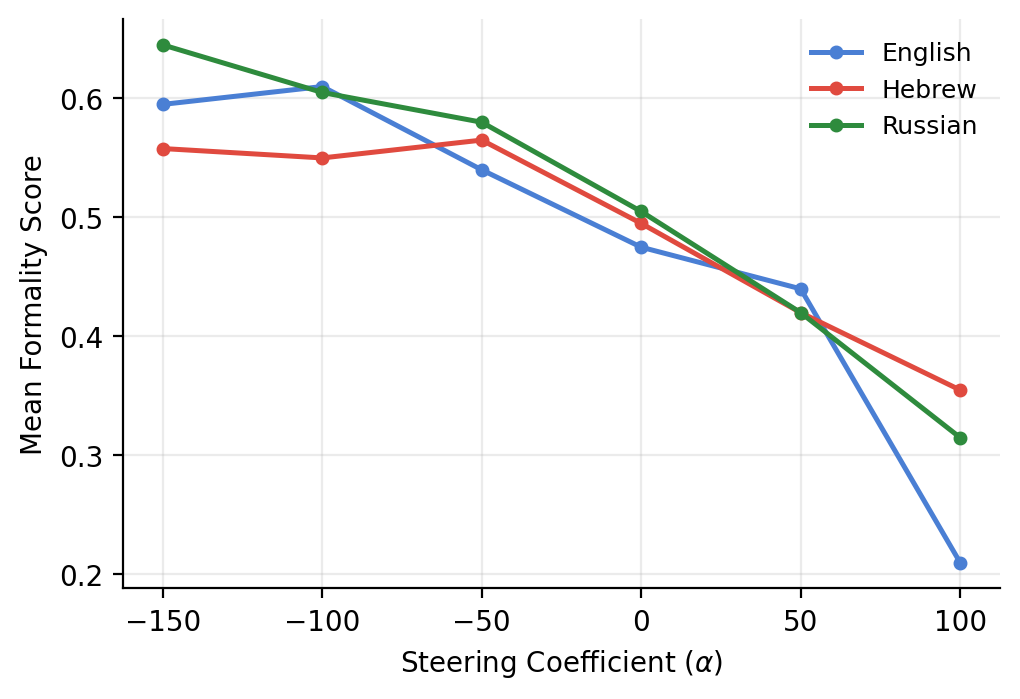

coefficient         -150   -100   -50     0     50     100
sentence_language                                         
english            0.595  0.610  0.540  0.475  0.44  0.210
hebrew             0.558  0.550  0.565  0.495  0.42  0.355
russian            0.645  0.605  0.580  0.505  0.42  0.315


In [ ]:
import matplotlib.pyplot as plt
if 'valid_df' not in globals():
    valid_df = pd.read_csv('/content/steering_scored_core10.csv')

SRC = ['english', 'hebrew', 'russian']
COEF = [-150, -100, -50, 0, 50, 100]
COL = {'english': '#4a7fd4', 'hebrew': '#e04a3f', 'russian': '#2e8b3d'}

d = valid_df[(valid_df.sentence_language.isin(SRC)) & (valid_df.coefficient.isin(COEF))]
fig, ax = plt.subplots(figsize=(5.2, 3.6), dpi=200)
for lang in SRC:
    g = d[d.sentence_language == lang].groupby('coefficient')['formality_score'].mean().reindex(COEF)
    ax.plot(g.index, g.values, marker='o', markersize=4, lw=1.8,
            color=COL[lang], label=lang.capitalize())
ax.set_xlabel(r'Steering Coefficient ($\alpha$)', fontsize=10)
ax.set_ylabel('Mean Formality Score', fontsize=10)
ax.set_xticks(COEF); ax.grid(alpha=0.25); ax.set_axisbelow(True)
for s in ('top','right'): ax.spines[s].set_visible(False)
ax.legend(fontsize=9, frameon=False)
plt.tight_layout()
plt.savefig('/content/source_lang_steering.png', dpi=300, bbox_inches='tight')
plt.show()
print(d.pivot_table(index='sentence_language', columns='coefficient',
                    values='formality_score', aggfunc='mean').round(3))

In [ ]:
# ============================================================================
# ISLAND SCORE: full accounting for §5.3
# ============================================================================
import gc, numpy as np
from sae_lens import SAE

CORE = {9:  [13485, 22467, 31252, 38266, 47673, 58884, 88558, 105792, 106322],
        20: [35440, 93521, 97003, 33236, 88782, 92777, 20069, 71479, 24006, 46374]}

N_RAND, N_SEEDS = 1000, 5          # identical to the PCA/figure cell
EXTRA_SEEDS = [0, 1, 42, 123, 200, 777]   # stability check only

def unit(x):
    return x / np.linalg.norm(x, axis=1, keepdims=True)

def get_dec(layer):
    """Reuse an already-loaded SAE if it matches this layer, else load it."""
    s = globals().get('sae', None)
    if s is not None and str(getattr(getattr(s, 'cfg', None), 'hook_name', '')).find(f'blocks.{layer}.') != -1:
        print(f"  reusing loaded SAE for layer {layer}")
        return s.W_dec.detach().float().cpu().numpy(), False
    print(f"  loading SAE for layer {layer} ...")
    _l = SAE.from_pretrained(release="gemma-scope-9b-it-res-canonical",
                             sae_id=f"layer_{layer}/width_131k/canonical", device="cpu")
    s = _l[0] if isinstance(_l, tuple) else _l
    return s.W_dec.detach().float().cpu().numpy(), True

rows = {}
for layer in (9, 20):
    print(f"\n{'='*70}\nLAYER {layer}\n{'='*70}")
    dec, loaded = get_dec(layer)
    assert dec.shape[0] == 131072, f"unexpected SAE width {dec.shape[0]}"

    feats = CORE[layer]
    G     = unit(dec[feats])
    pool  = np.setdiff1d(np.arange(dec.shape[0]), np.array(feats))

    # numerator: mean pairwise cosine inside the core (off-diagonal)
    within = (G @ G.T)[np.triu_indices(len(feats), 1)].mean()

    # denominator: mean |cos| between core and random features
    # also collect the signed core-to-random mean, and the within-random
    # pairwise mean (this last one is the "~0.001" figure currently in the text)
    absol, signed, rand_within = [], [], []
    for s in range(N_SEEDS):
        R = unit(dec[np.random.default_rng(s).choice(pool, N_RAND, replace=False)])
        M = G @ R.T
        absol.append(np.abs(M).mean())
        signed.append(M.mean())
        RR = R @ R.T
        rand_within.append(RR[np.triu_indices(N_RAND, 1)].mean())
    absol, signed, rand_within = map(lambda v: float(np.mean(v)), (absol, signed, rand_within))

    island = within / absol

    # seed stability of the ratio (numerator is fixed; only denominator moves)
    stab = []
    for sd in EXTRA_SEEDS:
        R = unit(dec[np.random.default_rng(sd).choice(pool, N_RAND, replace=False)])
        stab.append(within / np.abs(G @ R.T).mean())

    print(f"  n features                      : {len(feats)}")
    print(f"  within-group mean cosine        : {within:.4f}   -> paper: {within:.3f}")
    print(f"  core-to-random mean |cos|       : {absol:.5f}   (island DENOMINATOR)")
    print(f"  core-to-random mean signed cos  : {signed:+.5f}")
    print(f"  within-random mean pairwise cos : {rand_within:+.5f}   (the '~0.001' claim)")
    print(f"  ISLAND SCORE                    : {island:.2f}x  -> paper: {island:.1f}x")
    print(f"  seed stability {EXTRA_SEEDS}: " + ", ".join(f"{v:.2f}" for v in stab))
    print(f"  range {min(stab):.2f}-{max(stab):.2f}")

    rows[layer] = dict(n=len(feats), within=within, denom=absol,
                       signed=signed, rand_within=rand_within, island=island)

    del dec, G
    if loaded:
        gc.collect()

print(f"\n{'='*70}\nCOPY INTO §5.3\n{'='*70}")
for L in (9, 20):
    r = rows[L]
    print(f"  Layer {L:2d}: within {r['within']:.3f}  /  denom {r['denom']:.3f}  "
          f"=  {r['island']:.1f}x")
print(f"\n  random-baseline sentence should cite: "
      f"L9 {rows[9]['rand_within']:.4f}, L20 {rows[20]['rand_within']:.4f}")


LAYER 9
  loading SAE for layer 9 ...


layer_9/width_131k/average_l0_121/params(…): reconstructing file:   0%|          |  0.00B / 3.76GB            

layer_9/width_131k/average_l0_121/params(…): downloading bytes:           |  0.00B            

  n features                      : 9
  within-group mean cosine        : 0.0652   -> paper: 0.065
  core-to-random mean |cos|       : 0.01504   (island DENOMINATOR)
  core-to-random mean signed cos  : +0.00038
  within-random mean pairwise cos : +0.00070   (the '~0.001' claim)
  ISLAND SCORE                    : 4.34x  -> paper: 4.3x
  seed stability [0, 1, 42, 123, 200, 777]: 4.36, 4.38, 4.32, 4.33, 4.38, 4.36
  range 4.32-4.38

LAYER 20
  loading SAE for layer 20 ...
  n features                      : 10
  within-group mean cosine        : 0.1523   -> paper: 0.152
  core-to-random mean |cos|       : 0.01947   (island DENOMINATOR)
  core-to-random mean signed cos  : -0.00083
  within-random mean pairwise cos : +0.00137   (the '~0.001' claim)
  ISLAND SCORE                    : 7.82x  -> paper: 7.8x
  seed stability [0, 1, 42, 123, 200, 777]: 7.87, 7.85, 7.83, 7.85, 7.95, 7.87
  range 7.83-7.95

COPY INTO §5.3
  Layer  9: within 0.065  /  denom 0.015  =  4.3x
  Layer 20: within 0.152